In [23]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np  # ДОБАВЛЕНО

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [24]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [25]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [26]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [27]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [28]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7671986..1.3922839].


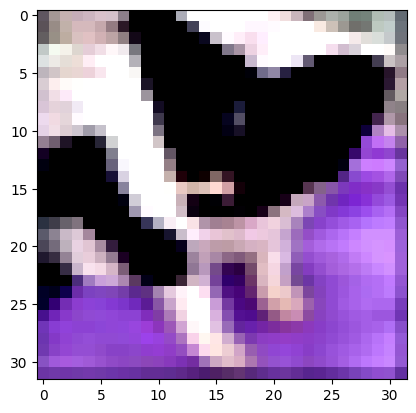

In [29]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

plt.show()  # ДОБАВЛЕНО

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [30]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [31]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [32]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [43]:
class Trainer:
    def __init__(self, config, model = 'cnn', transform=None):  # инициализация модели, оптимизатора, loss-функции и загрузчиков данных
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
        #ДОБАВЛЕНО
        if model == 'cnn':
            self.model = BasicCNN().to(self.device)
        elif model == 'resnet18':
            self.model = ResNet18().to(self.device)

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()
        
        # ДОБАВЛЕНО
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        
        self.setup_dataloaders()

    def setup_dataloaders(self):  # разделение данных на train/val/test
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):  # основной цикл обучения
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            # ДОБАВЛЕНО
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)
            
            print(f'Epoch {epoch + 1} / {self.config['num_epochs']}', train_loss, val_loss, val_acc)

        test_loss, self.test_acc = self.test_step()
        print(f'Test loss {test_loss:.4f}, test acc {self.test_acc:.2f}%')

        self.plot_losses_and_accuracies()
        return test_loss, self.test_acc  #ДОБАВЛЕНО
        
    def train_step(self):  # одна эпоха обучения
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):  # валидация
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):  # тестирование
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

    # ДОБАВЛЕНО
    def plot_losses_and_accuracies(self):
        epochs = range (1, self.config['num_epochs'] +1)
        plt.figure(figsize=(10,8))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_losses, label='train losess')
        plt.plot(epochs, self.val_losses, label='validation losses')
        plt.title('losses oveer epochs')
        plt.xlabel('epochs')
        plt.ylabel('losses')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot (epochs, self.train_accs, label = 'train acccuracies')
        plt.plot (epochs, self.val_accs, label = 'validation accuracies')
        
        if hasattr(self, 'test_acc'):
            plt.axhline(y=self.test_acc, color='r', linestyle='--', label=f'test accuracy: {self.test_acc:.2f}%')
        
        plt.title ('acccuracies over epochs')
        plt.xlabel('epochs')
        plt.ylabel('accuracies, %')
        plt.legend()
        plt.grid(True)
        plt.show()

In [44]:
trainer = Trainer(config, model = 'cnn', transform=transform)

100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:17<00:00,  4.53it/s]


Epoch 1 / 10 1.659206646699875 1.5020117291921302 45.129999999999995


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:14<00:00,  5.27it/s]


Epoch 2 / 10 1.434387036405813 1.4604924494707132 48.06


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:14<00:00,  5.40it/s]


...

Epoch 9 / 10 1.0551582468203462 1.2166032232815707 56.48


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:14<00:00,  5.55it/s]


Epoch 10 / 10 1.0414883545793283 1.215904557252232 57.220000000000006


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.93it/s]


Test loss 1.2241, test acc 55.86%


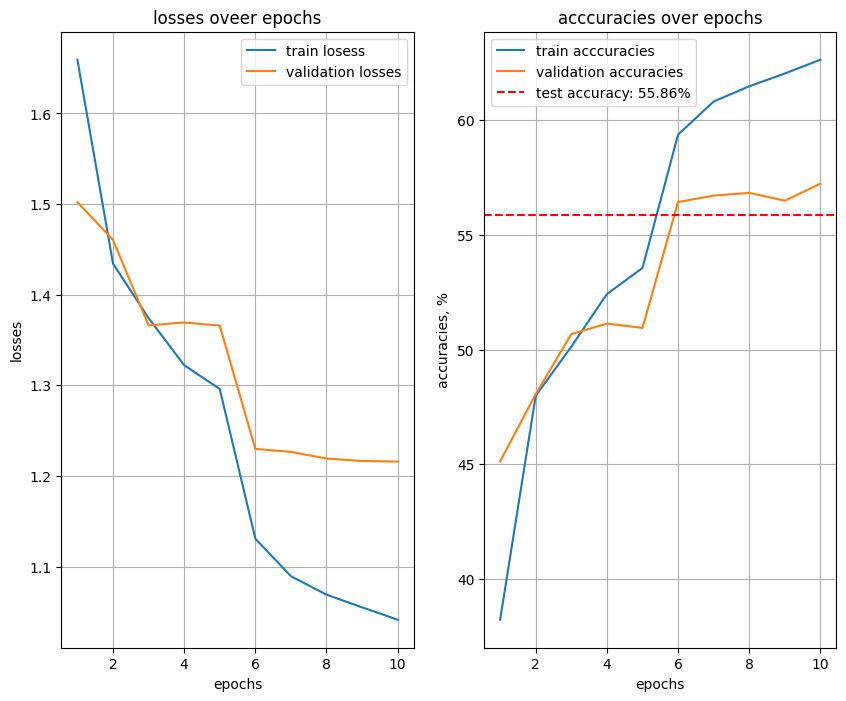

(1.224083540560324, 55.86)

In [45]:
trainer.run()

# ResNet-18

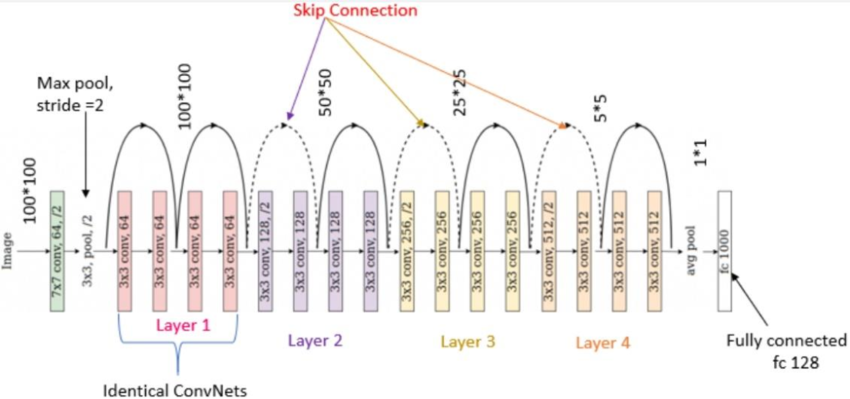

In [46]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)  # ДОБАВЛЕНО
        self.bn2 = nn.BatchNorm2d(out_channels)  # ДОБАВЛЕНО
        self.relu = nn.ReLU(inplace=True)  # ДОБАВЛЕНО

        self.downsample = downsample
        
    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(identity)

        # Применить свертки + skip connection
        # ДОБАВЛЕНО
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
      
        # ДОБАВЛЕНО
        out += identity
        out = self.relu(out)
        
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)  # ДОБАВЛЕНО
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Сделать 4 блока
        # Размеры: (каналы, высота, ширина)
        # (3,32,32) -> (64,16,16) -> (64,8,8) -> (64,8,8) -> 
        # (128,4,4) -> (256,2,2) -> (512,1,1) -> 512 -> 10
        self.layer1 = self.make_layer(64, 2)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
    def make_layer(self, out_channels, blocks, stride=1):
        # ДОБАВЛЕНО
        skip_connection = None
        
        if stride != 1 or out_channels != self.in_channels:
            skip_connection = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size = 1, stride = stride),
                nn.BatchNorm2d (out_channels)
            )
            
        blocks_list = []
        blocks_list.append(ResNetBlock(
            self.in_channels, 
            out_channels, 
            stride, 
            skip_connection
        ))
        
        self.in_channels = out_channels
        for idx in range (1, blocks):
            blocks_list.append(ResNetBlock(
                self.in_channels, 
                out_channels
            ))
        
        return nn.Sequential(*blocks_list)

    def forward(self, x):
        # сделать forward pass
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [47]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.76it/s]


Epoch 1 / 10 1.667045972217767 1.4752040482774567 46.910000000000004


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:15<00:00,  4.99it/s]


Epoch 2 / 10 1.3749723110716945 1.4511754648594917 48.010000000000005


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:17<00:00,  4.55it/s]


...

Epoch 9 / 10 0.9281534350718172 1.1007875030553793 61.519999999999996


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.94it/s]


Epoch 10 / 10 0.9085257775105607 1.1151211684263205 61.18


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.94it/s]


Test loss 1.1256, test acc 61.26%


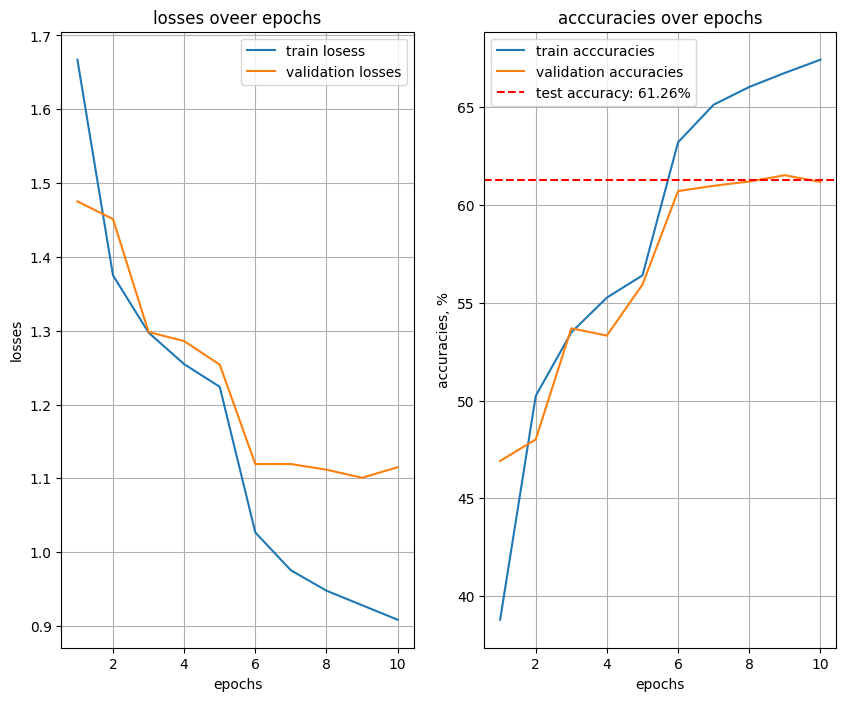

(1.125638385362263, 61.260000000000005)

In [48]:
trainer_cnn = Trainer(config, model='cnn', transform=transform)
trainer_cnn.run()

100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:26<00:00,  3.00it/s]


Epoch 1 / 10 1.8417090413669428 1.485704005519046 46.61


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:26<00:00,  2.95it/s]


Epoch 2 / 10 1.3431669730728808 1.3246794146827505 55.47


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:26<00:00,  2.97it/s]


...

Epoch 9 / 10 0.2758942307850804 0.8666530492939527 75.77000000000001


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:26<00:00,  3.02it/s]


Epoch 10 / 10 0.1998334413709732 0.9764737298217001 75.28


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:25<00:00,  3.08it/s]


Test loss 0.9953, test acc 74.57%


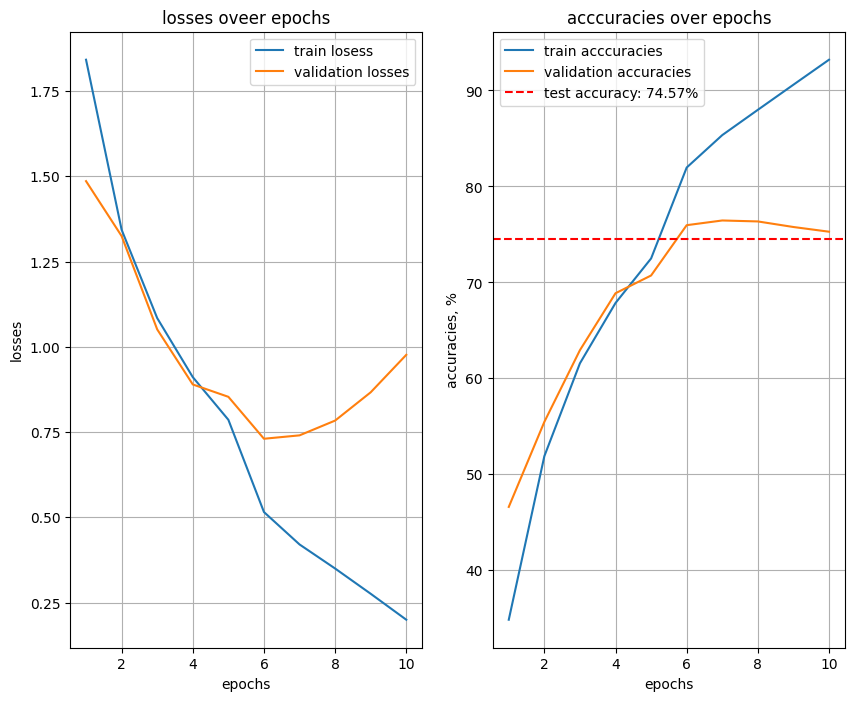

(0.9953487364551689, 74.57000000000001)

In [49]:
trainer_resnet18 = Trainer(config, model='resnet18', transform=transform)
trainer_resnet18.run()